# Setup

In [46]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

In [38]:
# Set the index when we import the data
df = pd.read_csv("weekly_customer_complaints.csv", index_col = "week", parse_dates=True)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [39]:
# Change the name of the time series variable t y
df = df.rename(columns = {"complaints": "y"})
df['y'] = df['y'].str.replace(',', '').astype('int32')
df.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750,37.26%,1,0,0
2018-01-08,1701,35.38%,0,0,0
2018-01-15,1711,36.22%,1,0,0
2018-01-22,1443,38.33%,1,0,0
2018-01-29,1397,36.34%,0,0,0


<Axes: xlabel='week'>

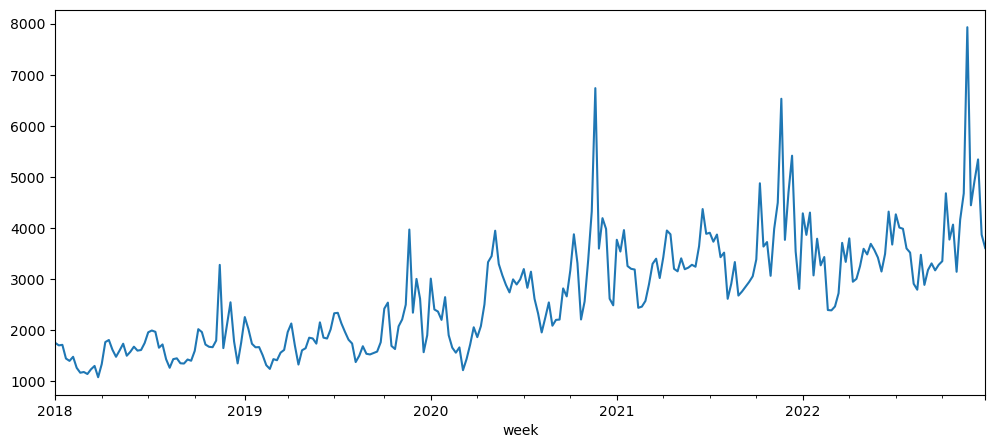

In [40]:
df['y'].plot(figsize=(12,5))

In [41]:
# Change the frequency
df = df.asfreq('W-MON')
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[us]', name='week', length=261, freq='W-MON')

# Data Visualization

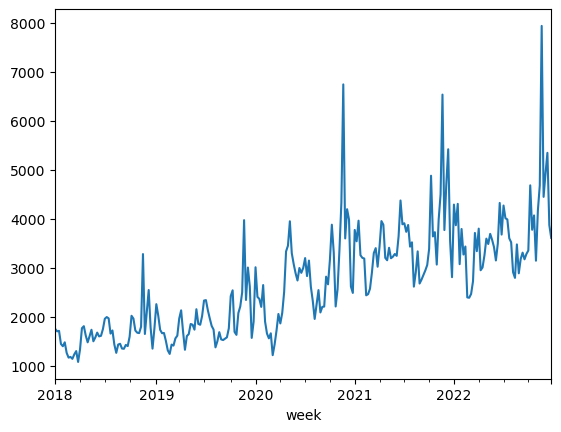

In [16]:
# Daily Closing Price Plot
df["y"].plot()
plt.show()

# Seasonality

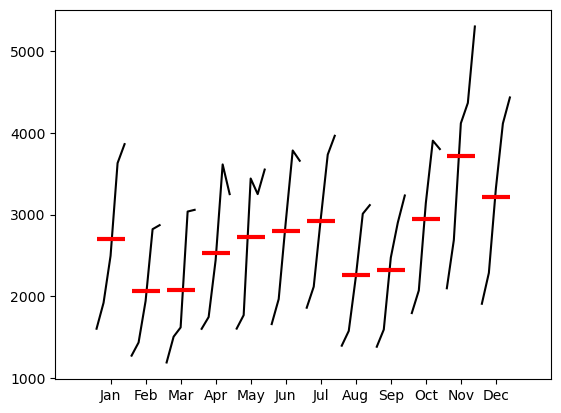

In [21]:
# Plot the month_plot
month_plot(df['y'].resample("ME").mean())
plt.show()

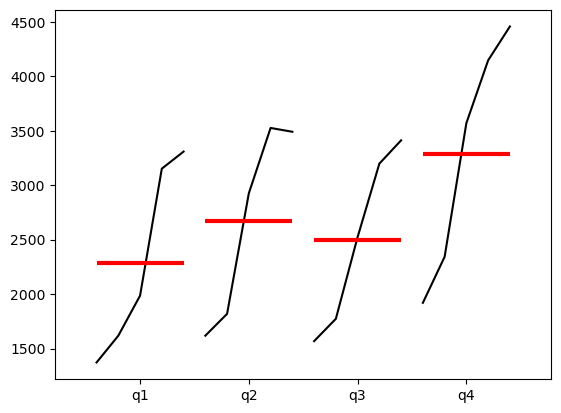

In [22]:
# Plot the quarter_plot
quarter_plot(df['y'].resample("QE").mean())
plt.show()

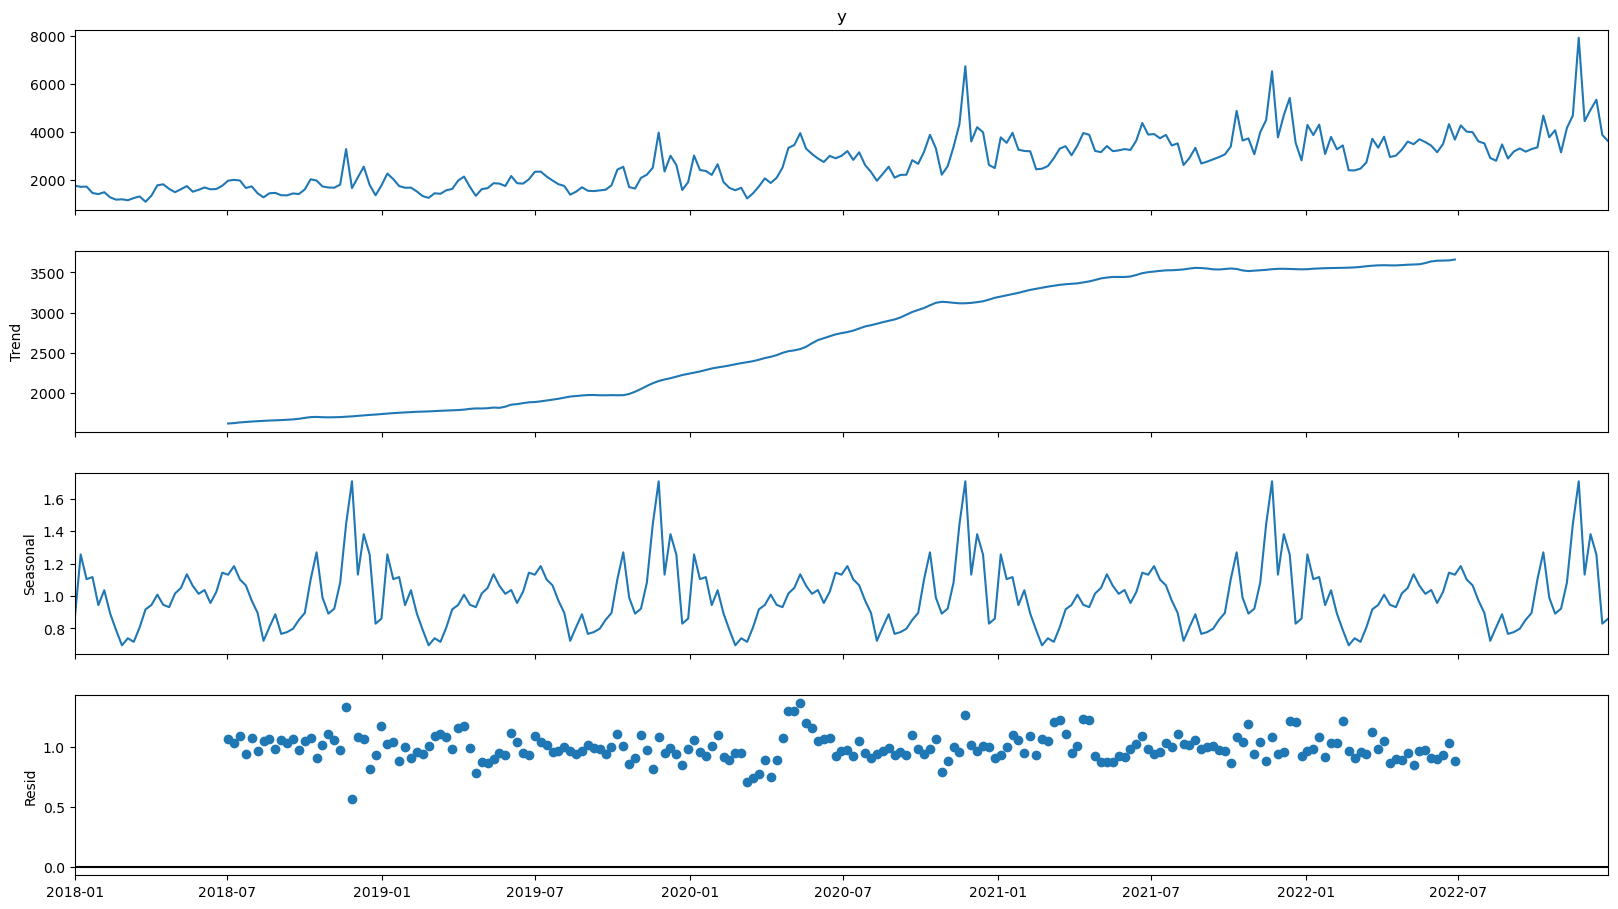

In [24]:
# Seasonal decomposition for df['Adj. Close']
decomposition = seasonal_decompose(df['y'],
                                  model = 'multiplicative',
                                  period = 52)
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()

# (Partial) Auto-Correlation

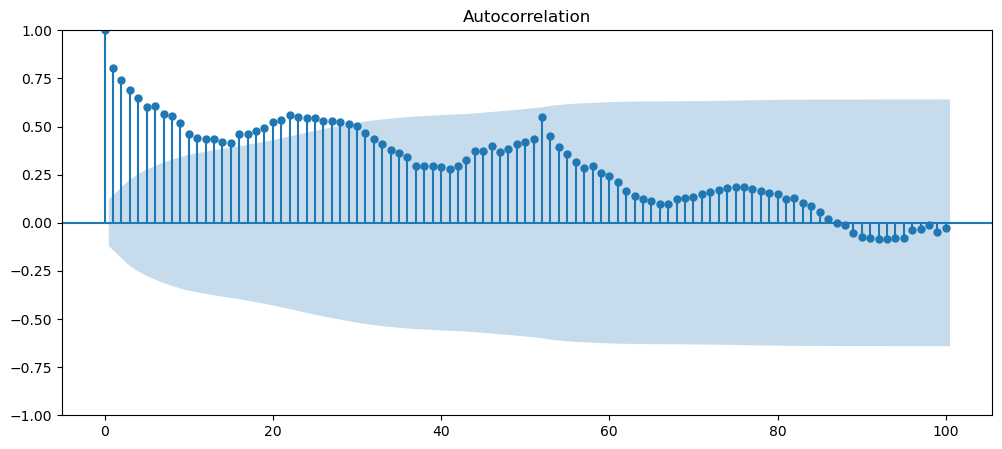

In [26]:
# Plot the ACF of the
fig, ax = plt.subplots(figsize = (12, 5))
plot_acf(df['y'], lags = 100, ax = ax)
plt.show()

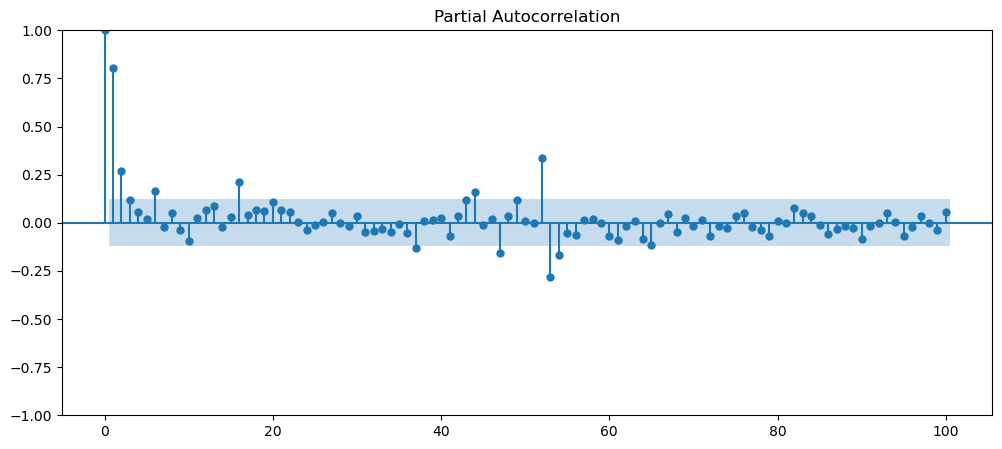

In [27]:
# PACF
fig, ax = plt.subplots(figsize = (12, 5))
plot_pacf(df['y'], lags = 100, ax = ax)
plt.show()

In [44]:
period = 13
train = df[:-period].y
test = df[-period:].y

## Simple Exponential smoothing  

In [49]:
ses_model = SimpleExpSmoothing(train).fit()
print(ses_model.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                      y   No. Observations:                  248
Model:             SimpleExpSmoothing   SSE                       74355478.081
Optimized:                       True   AIC                           3131.513
Trend:                           None   BIC                           3138.540
Seasonal:                        None   AICC                          3131.678
Seasonal Periods:                None   Date:                 Mon, 09 Mar 2026
Box-Cox:                        False   Time:                         17:55:22
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5097819                alpha                 True
initial_level              1750.0000                

# Model Assessment

In [ ]:
# Function that assesses the model and visualizes the train, test and forecast
def model_assessment(train, test, predictions, chart_title = None):
  # Set the chart size
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(train, label = "Train")
  plt.plot(test, label = "Test")
  plt.plot(predictions, label = "Forecast")
  plt.title(chart_title)
  plt.legend()
  plt.show()

  # Calculate and print the RMSE, MAE, and MAPE
  rmse = root_mean_squared_error(test, predictions)
  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  print(f"RMSE: {rmse:.0f}")
  print(f"MAE: {mae:.0f}")
  print(f"MAPE: {100 * mape:.1f} %")

# Plot the future

In [ ]:
def plot_future(y, forecast, chart_title = None):
  # Plot the training data and forecast
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(y, label = "Train")
  plt.plot(forecast, label = "Forecast")

  # Add a title and legend to the plot
  plt.title(chart_title)
  plt.legend()
  plt.show()
